In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pickle

#dataset load krwane mai help karegi
from datasets import load_dataset

In [22]:
emotion_dataset = load_dataset('dair-ai/emotion')

train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

# IMPROVED: load the real validation split instead of reusing test as validation
val_text = emotion_dataset['validation']['text']
val_label = emotion_dataset['validation']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [23]:
label_names = emotion_dataset['train'].features['label'].names

In [24]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [25]:
df_train = pd.DataFrame({'text': train_text, 'label': [label_names[i] for i in train_label]})
df_val   = pd.DataFrame({'text': val_text,   'label': [label_names[i] for i in val_label]})
df_test  = pd.DataFrame({'text': test_text,  'label': [label_names[i] for i in test_label]})

In [26]:
df_train.isnull().sum()

,0
text,0
label,0


In [27]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


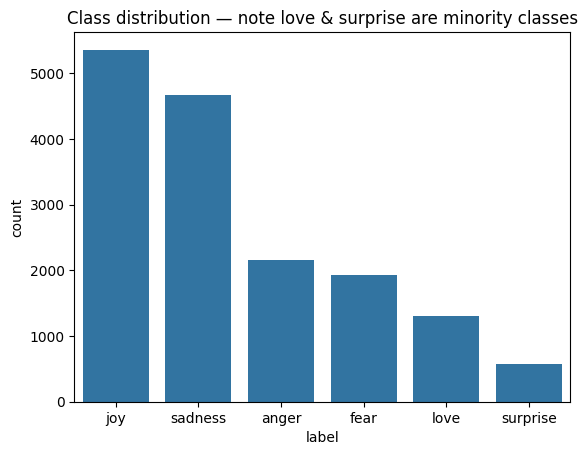

In [28]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)
plt.title('Class distribution — note love & surprise are minority classes')
plt.show()

In [29]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 15000   # IMPROVED: was 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')  # IMPROVED: was oov_token=''
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
val_sequence   = tokenizer.texts_to_sequences(df_val['text'])    # IMPROVED: tokenize validation split
test_sequence  = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=max_len, padding='post', truncating='post')
padded_val_sequence   = pad_sequences(val_sequence,   maxlen=max_len, padding='post', truncating='post')
padded_test_sequence  = pad_sequences(test_sequence,  maxlen=max_len, padding='post', truncating='post')

train_labels = np.array(train_label)
val_labels   = np.array(val_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f'Vocabulary size seen: {len(tokenizer.word_index)}')
print(f'Vocabulary size used (num_words cap): {max_words}')
print(f'Max sentence length: {padded_train_sequence.shape[1]}')

Vocabulary size seen: 15213
Vocabulary size used (num_words cap): 15000
Max sentence length: 50


In [31]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [32]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

os.makedirs('Artifacts', exist_ok=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# IMPROVED: new callbacks
checkpoint = ModelCheckpoint(
    filepath='Artifacts/best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dropout, SpatialDropout1D, Dense

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300),
    SpatialDropout1D(0.3),                                              # IMPROVED
    Bidirectional(GRU(128, return_sequences=True, recurrent_dropout=0.2)),  # IMPROVED: recurrent_dropout
    Dropout(0.5),
    Bidirectional(GRU(64, recurrent_dropout=0.2)),                      # IMPROVED: recurrent_dropout
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiGRU.build(input_shape=(None, max_len))
BiGRU.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 300)        │     4,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 300)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,954,662 (18.90 MB)

 Trainable params: 4,954,662 (18.90 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),   # IMPROVED: real validation split, not test
    epochs=30,                                            # IMPROVED: raised cap, ReduceLROnPlateau + EarlyStopping manage it
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, checkpoint, reduce_lr]    # IMPROVED
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 292s 550ms/step - accuracy: 0.5076 - loss: 1.2217 - val_accuracy: 0.8705 - val_loss: 0.4047 - learning_rate: 0.0010
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 254s 507ms/step - accuracy: 0.9062 - loss: 0.2838 - val_accuracy: 0.9145 - val_loss: 0.2397 - learning_rate: 0.0010
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 253s 507ms/step - accuracy: 0.9427 - loss: 0.1576 - val_accuracy: 0.9245 - val_loss: 0.2187 - learning_rate: 0.0010
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 264s 510ms/step - accuracy: 0.9557 - loss: 0.1218 - val_accuracy: 0.9340 - val_loss: 0.1965 - learning_rate: 0.0010
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 254s 509ms/step - accuracy: 0.9671 - loss: 0.0881 - val_accuracy: 0.9325 - val_loss: 0.2331 - learning_rate: 0.0010
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 261s 507ms/step - accuracy: 0.9745 - loss: 0.0733 - val_accuracy: 0.9250 - val_loss: 0.2789 - learning_rate: 0.0010
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 262s 506ms/step - accura

In [35]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f'BiGRU Test Loss: {BiGRU_loss}')
print(f'BiGRU Test Accuracy: {BiGRU_accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9235 - loss: 0.2267
BiGRU Test Loss: 0.22668346762657166
BiGRU Test Accuracy: 0.9235000014305115


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step
              precision    recall  f1-score   support

     sadness       0.99      0.94      0.96       581
         joy       0.97      0.92      0.94       695
        love       0.78      0.94      0.85       159
       anger       0.91      0.95      0.93       275
        fear       0.91      0.84      0.88       224
    surprise       0.61      0.94      0.74        66

    accuracy                           0.92      2000
   macro avg       0.86      0.92      0.88      2000
weighted avg       0.93      0.92      0.93      2000



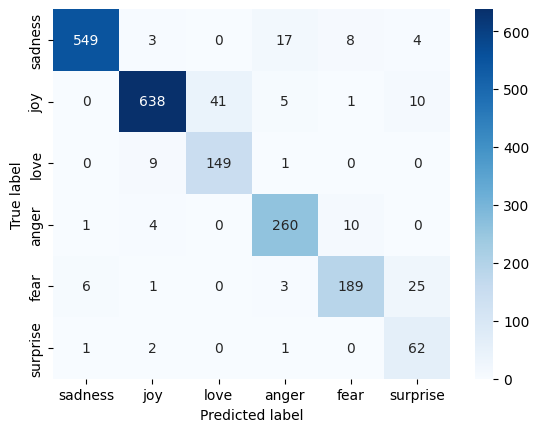

In [36]:
from sklearn.metrics import confusion_matrix, classification_report

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

print(classification_report(test_labels, BiGRU_predictions, target_names=label_names))

sns.heatmap(confusion_matrix(test_labels, BiGRU_predictions), annot=True, fmt='d',
            cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [37]:
def predict_emotion(text, model=BiGRU, tok=tokenizer, maxlen=max_len, labels=label_names, return_probs=False):
    seq = tok.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=maxlen, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    if return_probs:
        return labels[pred_idx], dict(zip(labels, probs.tolist()))
    return labels[pred_idx]

sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!",
    "I am happy",                    # IMPROVED: short, plain-spoken test case
    "I love my girlfriend",          # IMPROVED: short, plain-spoken test case
]

for t in sample_texts:
    label, probs = predict_emotion(t, return_probs=True)
    top3 = sorted(probs.items(), key=lambda x: -x[1])[:3]
    print(f'Text: {t}')
    print(f'  Predicted: {label}')
    print(f'  Top 3: {top3}')
    print()

Text: I can't believe how happy I am right now, this is amazing!
  Predicted: surprise
  Top 3: [('surprise', 0.8693569898605347), ('fear', 0.07269542664289474), ('joy', 0.03056451305747032)]

Text: I feel so alone and hopeless today.
  Predicted: sadness
  Top 3: [('sadness', 0.9997114539146423), ('surprise', 9.776414663065225e-05), ('anger', 9.372280328534544e-05)]

Text: I am furious that they cancelled the trip at the last minute.
  Predicted: anger
  Top 3: [('anger', 0.9854831695556641), ('fear', 0.010612152516841888), ('sadness', 0.0021705329418182373)]

Text: I feel terrified when walking down dark alleyways alone.
  Predicted: fear
  Top 3: [('fear', 0.9987170696258545), ('surprise', 0.0006619766936637461), ('anger', 0.00044518118374980986)]

Text: I was shocked and completely surprised by the unexpected gift!
  Predicted: surprise
  Top 3: [('surprise', 0.9618300795555115), ('fear', 0.026246484369039536), ('joy', 0.006704724859446287)]

Text: I am happy
  Predicted: anger
  T

In [38]:
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

BiGRU.save(os.path.join(model_dir, 'BiGRU_model.keras'))

with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)

# IMPROVED: persist config needed for correct inference elsewhere
with open(os.path.join(model_dir, 'config.pkl'), 'wb') as f:
    pickle.dump({'max_len': max_len, 'label_names': label_names}, f)

print('Saved model, tokenizer, and config to', model_dir)

Saved model, tokenizer, and config to Artifacts


In [40]:
## If you deploy this elsewhere (Flask app, API, etc.)

# Load all three artifacts together and reuse the same `predict_emotion` logic — never re-instantiate a fresh `Tokenizer()`:
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = load_model('Artifacts/BiGRU_model.keras')
with open('Artifacts/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('Artifacts/config.pkl', 'rb') as f:
    config = pickle.load(f)

def predict_emotion(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=config['max_len'], padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    return config['label_names'][probs.argmax()]
